# Distributed QFT

This notebook shows the distributed QFT comparison on the fixed 156-qubit chip model, including node placement, communication costs, Aer results, and the non-local execution log.


In [2]:
import sys
from pathlib import Path

CURRENT_DIR = Path.cwd()
PARENT_DIR = CURRENT_DIR.parent
STANDARD_DIR = PARENT_DIR / "standard_qft"
for candidate in (CURRENT_DIR, PARENT_DIR, STANDARD_DIR):
    if str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

import numpy as np
from IPython.display import display

try:
    import matplotlib.pyplot as plt
    HISTOGRAMS_AVAILABLE = True
except Exception:
    plt = None
    HISTOGRAMS_AVAILABLE = False

from qiskit_ibm_runtime.fake_provider import FakeFez

from distributed_qft_blocks import (
    build_cat_disentangler_block,
    build_cat_entangler_block,
    build_nonlocal_controlled_phase_demo,
    build_teleportation_leg_demo,
    build_teleportation_swap_demo,
)
from distributed_qft_comparison import (
    build_node_mapping,
    collect_method_report,
    choose_best_method,
    distributed_chip_layout,
)
from qft.standard_qft import build_standard_qft, build_recursive_qft
from qft_sampler_utils import build_sample_amplitudes, total_variation_distance
from qft_visualization_utils import show_circuit


def show_histogram(data, legend, title, top_n=12):
    print(f"\n{title}")
    all_labels = sorted({label for counts in data for label, value in counts.items() if value > 0})
    all_labels.sort(key=lambda label: sum(counts.get(label, 0) for counts in data), reverse=True)
    labels = all_labels[:top_n]

    if not HISTOGRAMS_AVAILABLE:
        print("matplotlib is not installed in this environment, so showing raw counts instead.")
        for series_label, counts in zip(legend, data):
            filtered = {label: counts.get(label, 0) for label in labels}
            print(series_label + ":", filtered)
        return

    width = 0.8 / max(len(data), 1)
    x = np.arange(len(labels), dtype=float)
    fig_width = max(12, len(labels) * 1.2)
    fig, ax = plt.subplots(figsize=(fig_width, 6))

    for index, (series_label, counts) in enumerate(zip(legend, data)):
        values = [counts.get(label, 0) for label in labels]
        offset = (index - (len(data) - 1) / 2) * width
        bars = ax.bar(x + offset, values, width=width, label=series_label)
        for bar, value in zip(bars, values):
            if value > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    value + 0.5,
                    str(value),
                    ha="center",
                    va="bottom",
                    fontsize=9,
                )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_ylabel("Counts")
    subtitle = f"Top {len(labels)} outcomes" if len(labels) < len(all_labels) else "All non-zero outcomes"
    ax.set_title(f"{title} ({subtitle})")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    fig.tight_layout()
    display(fig)
    plt.close(fig)

    if len(labels) < len(all_labels):
        print(f"Showing the top {len(labels)} outcomes out of {len(all_labels)} non-zero outcomes.")


In [3]:
num_qubits = 6
num_nodes = 3
strategy = "contiguous"
shots = 128

node_mapping = build_node_mapping(num_qubits, num_nodes, strategy)
chip_layout = distributed_chip_layout()
backend = FakeFez()
amplitudes = build_sample_amplitudes(num_qubits)

standard_report = collect_method_report(
    "Standard QFT method",
    build_standard_qft,
    num_qubits,
    node_mapping,
    amplitudes,
    backend,
    shots,
)
recursive_report = collect_method_report(
    "Recursive QFT",
    build_recursive_qft,
    num_qubits,
    node_mapping,
    amplitudes,
    backend,
    shots,
)
reports = [standard_report, recursive_report]
best_method = choose_best_method(reports)

print("Using fake backend:", backend.name)
print("Node mapping:", node_mapping)
print("Physical mapping (standard report):", standard_report["physical_qubit_mapping"])
print("Chip layout:", chip_layout)
print("Recommended method:", best_method["method"])


Using fake backend: fake_fez
Node mapping: {0: 0, 1: 0, 2: 1, 3: 1, 4: 2, 5: 2}
Physical mapping (standard report): {0: 0, 1: 1, 2: 50, 3: 51, 4: 100, 5: 101}
Chip layout: {'backend_name': 'fake_fez', 'total_physical_qubits': 156, 'nodes': [{'node': 0, 'physical_qubit_range': [0, 49], 'capacity': 50}, {'node': 1, 'physical_qubit_range': [50, 99], 'capacity': 50}, {'node': 2, 'physical_qubit_range': [100, 149], 'capacity': 50}], 'unused_physical_qubit_range': [150, 155]}
Recommended method: Standard QFT method


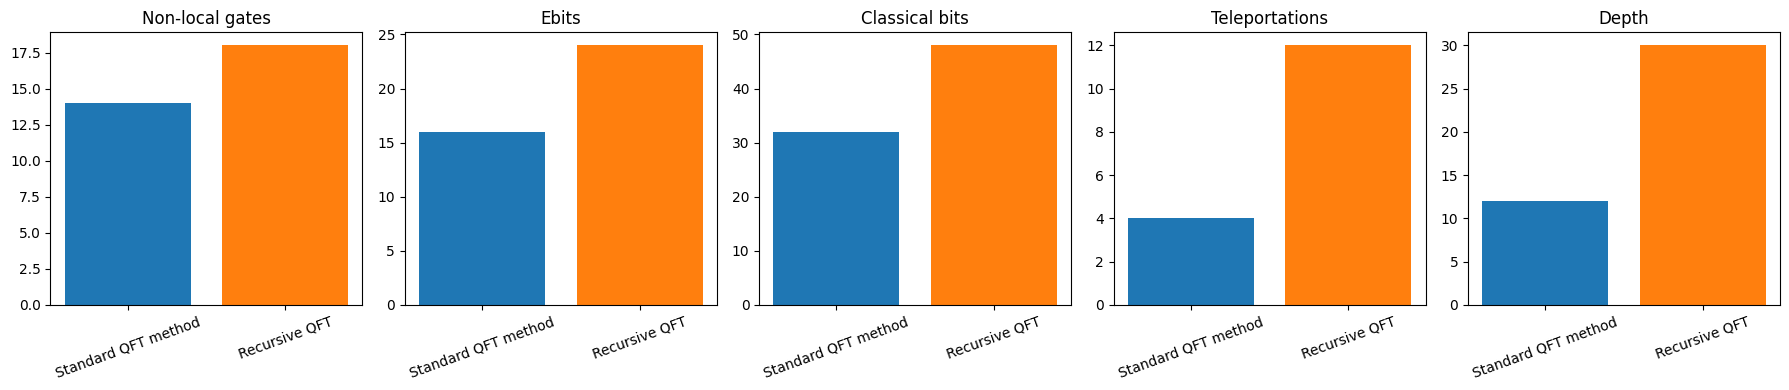

In [4]:
labels = [report["method"] for report in reports]
metrics = {
    "Non-local gates": [report["nonlocal_gate_total"] for report in reports],
    "Ebits": [report["shared_entangled_pairs"] for report in reports],
    "Classical bits": [report["classical_bits"] for report in reports],
    "Teleportations": [report["teleportations"] for report in reports],
    "Depth": [report["total_depth"] for report in reports],
}

fig, axes = plt.subplots(1, len(metrics), figsize=(18, 4))
for axis, (title, values) in zip(axes, metrics.items()):
    axis.bar(labels, values, color=["#1f77b4", "#ff7f0e"])
    axis.set_title(title)
    axis.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()



Standard QFT method
Ideal Aer top outcomes: [('000000', 102), ('000001', 10), ('111111', 7), ('000010', 4), ('000111', 1), ('001000', 1), ('101111', 1), ('111010', 1)]
Noisy Aer top outcomes: [('000000', 53), ('000001', 11), ('000010', 9), ('111000', 4), ('111100', 4), ('000100', 3), ('000110', 3), ('111111', 3)]

Recursive QFT
Ideal Aer top outcomes: [('000000', 92), ('111111', 12), ('000001', 11), ('000010', 6), ('111110', 3), ('010001', 1), ('100011', 1), ('110010', 1)]
Noisy Aer top outcomes: [('000000', 55), ('000001', 12), ('100000', 8), ('111111', 8), ('111000', 4), ('000010', 3), ('010000', 3), ('111110', 3)]

Ideal Aer TVD between methods: 0.1172
Noisy Aer TVD between methods: 0.2266

Distributed QFT ideal Aer counts


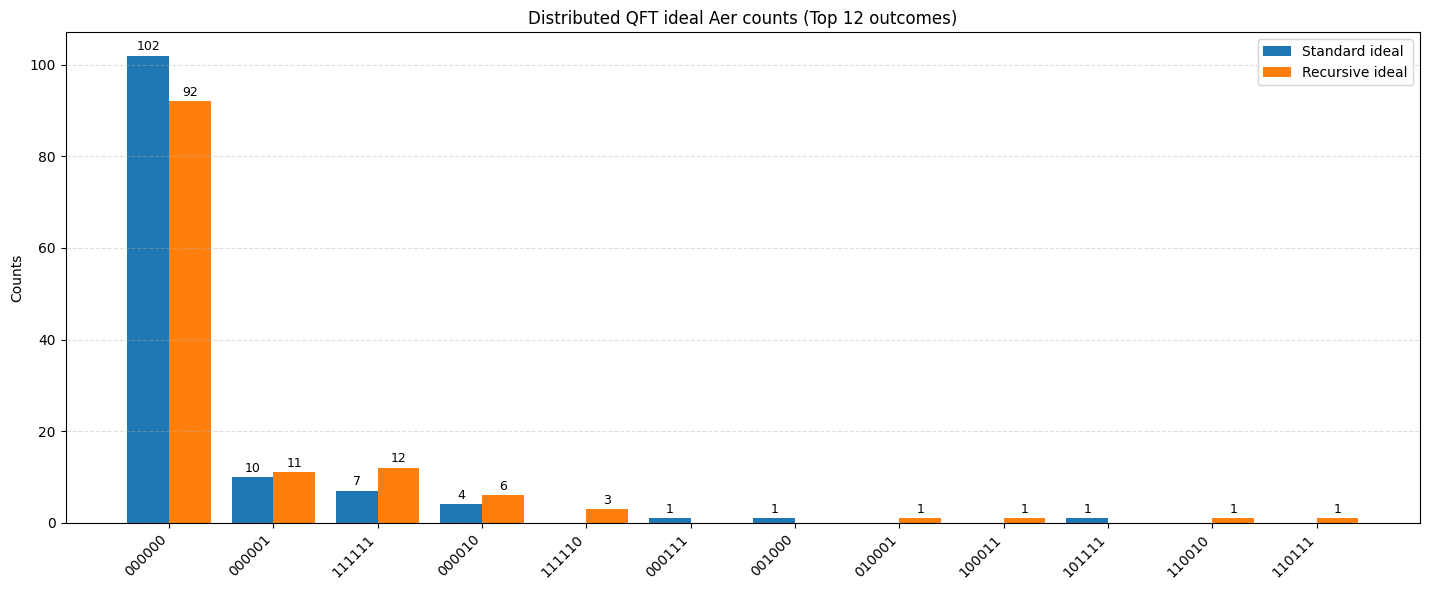

Showing the top 12 outcomes out of 14 non-zero outcomes.

Distributed QFT noisy Aer counts


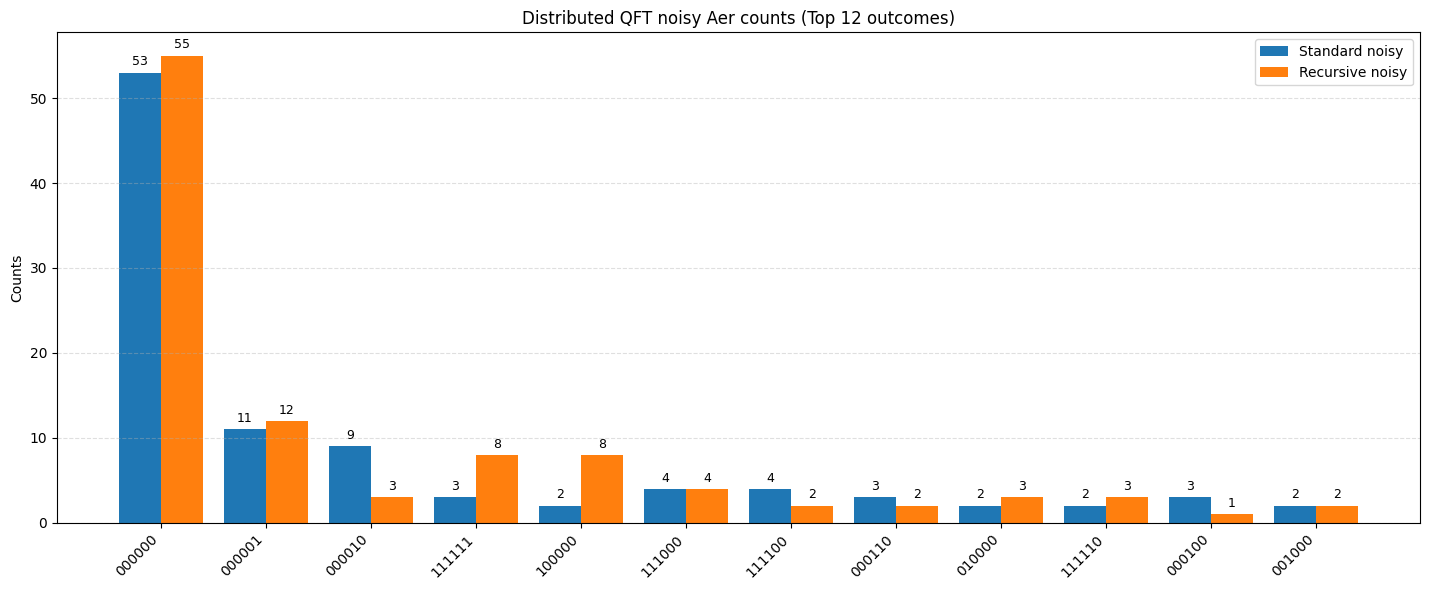

Showing the top 12 outcomes out of 46 non-zero outcomes.


In [5]:
for report in reports:
    print(f"\n{report['method']}")
    print("Ideal Aer top outcomes:", report["aer"]["ideal"]["top_outcomes"])
    print("Noisy Aer top outcomes:", report["aer"]["noisy"]["top_outcomes"])

ideal_tvd = total_variation_distance(reports[0]["aer"]["ideal"]["counts"], reports[1]["aer"]["ideal"]["counts"])
noisy_tvd = total_variation_distance(reports[0]["aer"]["noisy"]["counts"], reports[1]["aer"]["noisy"]["counts"])
print("\nIdeal Aer TVD between methods:", round(ideal_tvd, 4))
print("Noisy Aer TVD between methods:", round(noisy_tvd, 4))

show_histogram([reports[0]["aer"]["ideal"]["counts"], reports[1]["aer"]["ideal"]["counts"]], legend=["Standard ideal", "Recursive ideal"], title="Distributed QFT ideal Aer counts")
show_histogram([reports[0]["aer"]["noisy"]["counts"], reports[1]["aer"]["noisy"]["counts"]], legend=["Standard noisy", "Recursive noisy"], title="Distributed QFT noisy Aer counts")


In [6]:
for report in reports:
    print(f"\nNon-local execution log for {report['method']}:")
    for entry in report["execution_log"]:
        if entry["locality"] == "non-local":
            print(f"  Step {entry['step']}: {entry['gate']} on qubits {entry['qubits']} across nodes {entry['nodes']} -> {entry['action']}")



Non-local execution log for Standard QFT method:
  Step 3: cp on qubits [3, 5] across nodes [1, 2] -> Create a distributed control block from node 1 to node 2, then apply cp on the target node.
  Step 4: cp on qubits [2, 5] across nodes [1, 2] -> Create a distributed control block from node 1 to node 2, then apply cp on the target node.
  Step 5: cp on qubits [1, 5] across nodes [0, 2] -> Create a distributed control block from node 0 to node 2, then apply cp on the target node.
  Step 6: cp on qubits [0, 5] across nodes [0, 2] -> Create a distributed control block from node 0 to node 2, then apply cp on the target node.
  Step 8: cp on qubits [3, 4] across nodes [1, 2] -> Create a distributed control block from node 1 to node 2, then apply cp on the target node.
  Step 9: cp on qubits [2, 4] across nodes [1, 2] -> Create a distributed control block from node 1 to node 2, then apply cp on the target node.
  Step 10: cp on qubits [1, 4] across nodes [0, 2] -> Create a distributed contr


Cat-entangler block


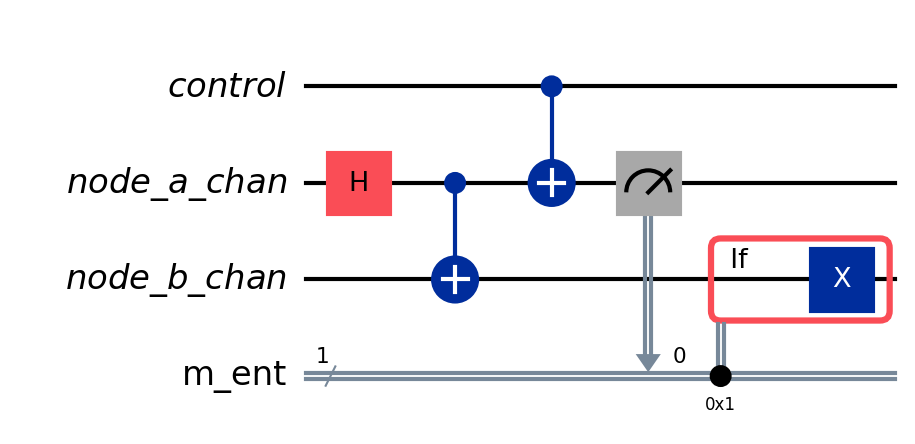


Cat-disentangler block


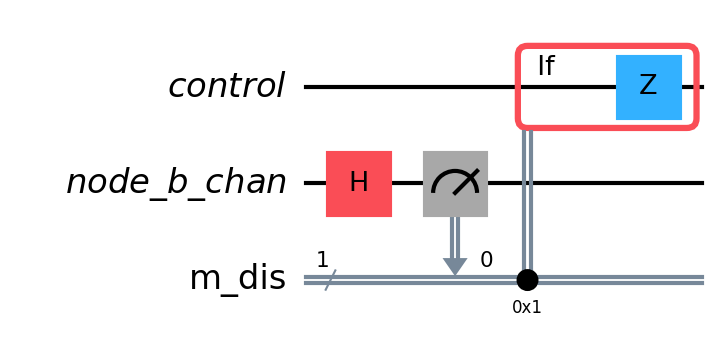


Entanglement-assisted non-local controlled-phase block


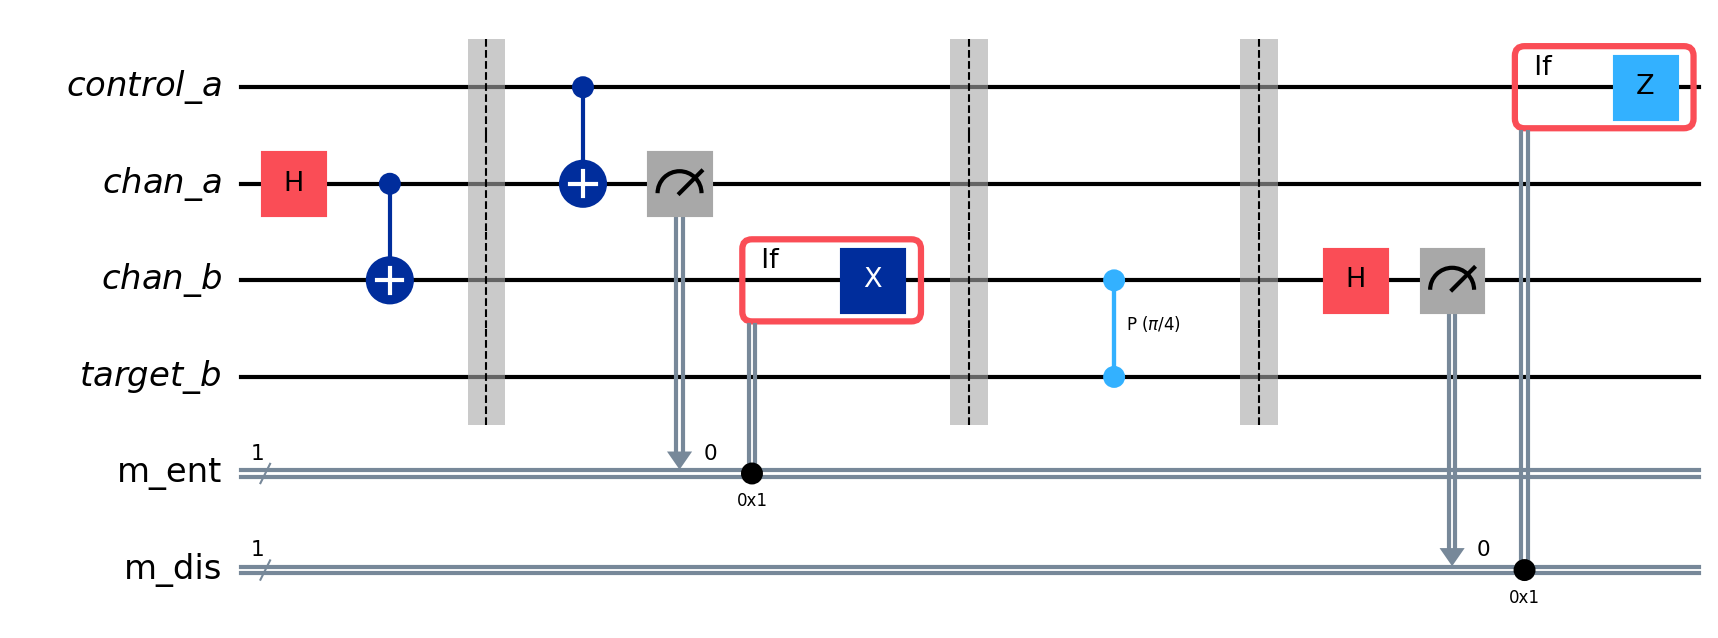


Single teleportation leg


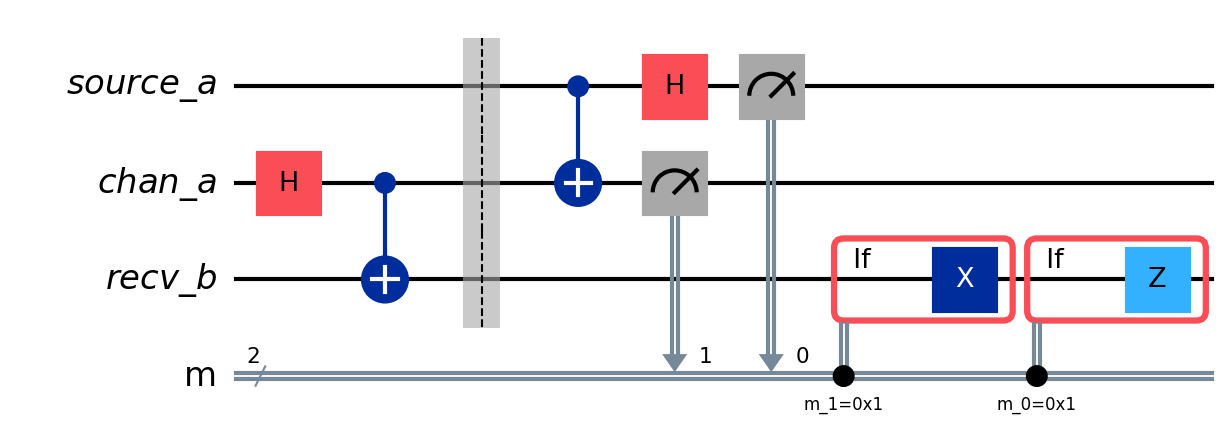


Distributed swap built from teleportation


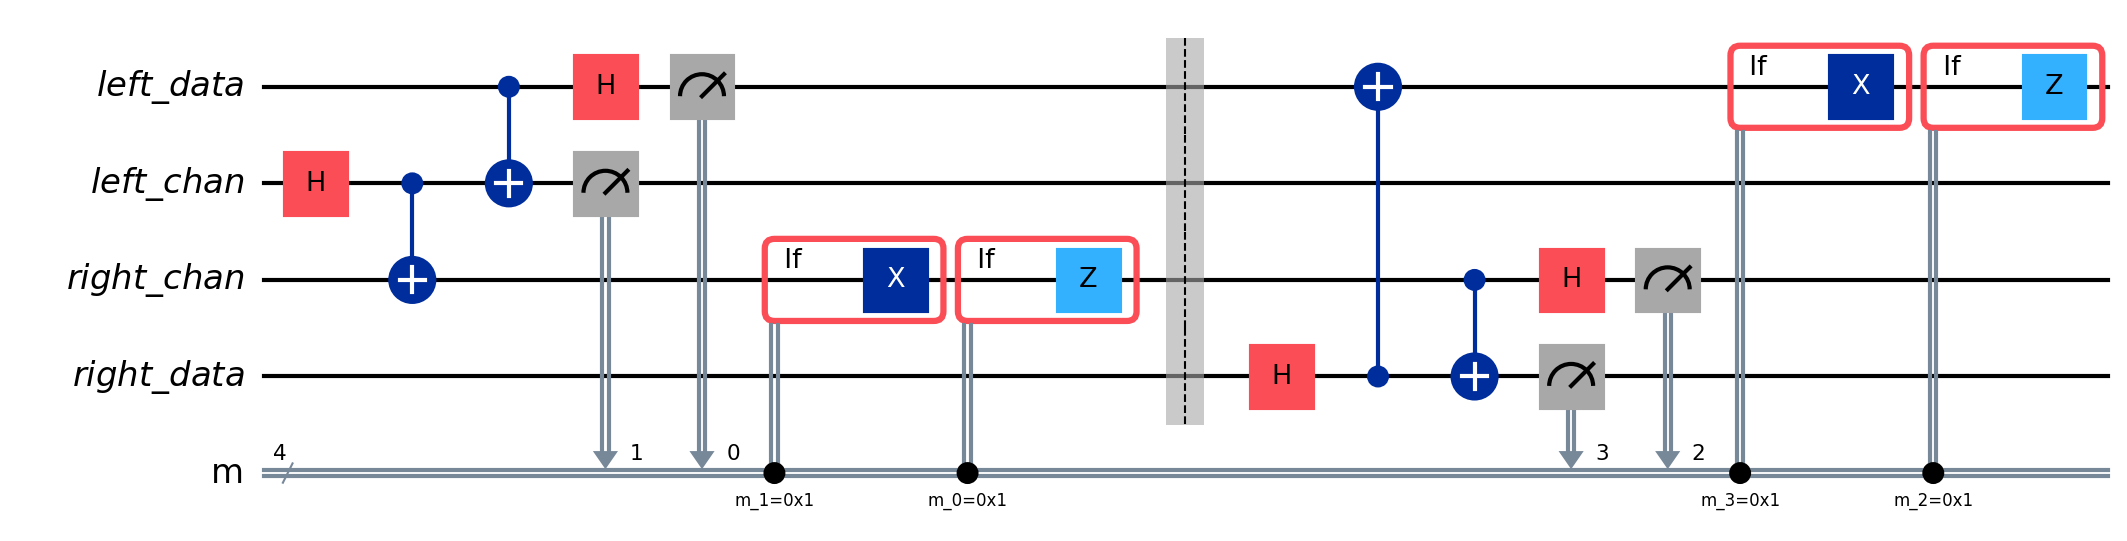

In [7]:
show_circuit(build_cat_entangler_block(), "Cat-entangler block")
show_circuit(build_cat_disentangler_block(), "Cat-disentangler block")
show_circuit(build_nonlocal_controlled_phase_demo(), "Entanglement-assisted non-local controlled-phase block")
show_circuit(build_teleportation_leg_demo(), "Single teleportation leg")
show_circuit(build_teleportation_swap_demo(), "Distributed swap built from teleportation")
